# Mobile Customer Churn Prediction

Dataset: `mobile_customers.csv`, 17799 khách hàng, 13 cột. Target: `brand_churn` (0 = stay, 1 = churn).

Các bước: EDA -> Preprocessing & Feature Selection -> Model Training (so sánh nhiều model) -> Results.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import mutual_info_classif
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay
)

%matplotlib inline
sns.set_style("whitegrid")
RANDOM_STATE = 42

## 1. EDA

In [2]:
df = pd.read_csv("data/mobile_customers.csv")
print(df.shape)
df.head()

(17799, 13)


,id,college,income,overage,leftover,house,init_payment,over_15min,call_duration,satisfaction,usage_level,change_plan,brand_churn
0,2,1.0,36147,0,13,800586.0,244,0,6,unsat,little,considering,0
1,4,0.0,120070,38,33,788235.0,780,3,2,unsat,very_high,considering,1
2,5,NaN,29215,208,85,224784.0,241,21,1,very_unsat,little,never_thought,0
3,6,NaN,133728,64,48,632969.0,626,3,2,unsat,high,no,0
4,8,NaN,84744,0,20,688098.0,357,0,5,very_unsat,little,considering,0


In [3]:
df.dtypes

id                 int64
college          float64
income             int64
overage            int64
leftover             str
house            float64
init_payment       int64
over_15min         int64
call_duration      int64
satisfaction         str
usage_level          str
change_plan          str
brand_churn        int64
dtype: object

In [4]:
# leftover bi doc thanh string do 1 gia tri dung dau phay ("0,000001")
df.loc[~df["leftover"].str.match(r"^-?\d+\.?\d*$", na=False), "leftover"]

462    0,000001
Name: leftover, dtype: str

In [5]:
df["leftover"] = df["leftover"].str.replace(",", ".", regex=False).astype(float)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 17799 entries, 0 to 17798
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             17799 non-null  int64  
 1   college        10811 non-null  float64
 2   income         17799 non-null  int64  
 3   overage        17799 non-null  int64  
 4   leftover       17799 non-null  float64
 5   house          17586 non-null  float64
 6   init_payment   17799 non-null  int64  
 7   over_15min     17799 non-null  int64  
 8   call_duration  17799 non-null  int64  
 9   satisfaction   16903 non-null  str    
 10  usage_level    17799 non-null  str    
 11  change_plan    17799 non-null  str    
 12  brand_churn    17799 non-null  int64  
dtypes: float64(3), int64(7), str(3)
memory usage: 1.8 MB


In [6]:
df.describe()

,id,college,income,overage,leftover,house,init_payment,over_15min,call_duration,brand_churn
count,17799.000000,10811.000000,17799.000000,17799.000000,17799.000000,17586.000000,1.779900e+04,17799.000000,17799.000000,17799.000000
mean,10001.665150,0.507261,80319.004832,86.022529,24.006349,493036.173661,5.774340e+02,8.013372,5.987977,0.493230
std,5767.704974,0.499970,41727.401143,85.946044,26.871586,252250.801878,2.498285e+04,8.935281,4.399120,0.499968
min,2.000000,0.000000,20007.000000,-2.000000,0.000000,150015.000000,1.300000e+02,0.000000,1.000000,0.000000
25%,5006.500000,0.000000,42073.500000,0.000000,0.000000,263879.750000,2.190000e+02,1.000000,2.000000,0.000000
50%,10001.000000,1.000000,75505.000000,59.000000,14.000000,452528.500000,3.260000e+02,4.000000,5.000000,0.000000
75%,14990.500000,1.000000,116138.500000,179.000000,42.000000,701586.750000,5.360000e+02,15.000000,10.000000,1.000000
max,20000.000000,1.000000,159983.000000,335.000000,89.000000,999970.000000,3.333302e+06,29.000000,15.000000,1.000000


In [7]:
df.isna().sum()

id                  0
college          6988
income              0
overage             0
leftover            0
house             213
init_payment        0
over_15min          0
call_duration       0
satisfaction      896
usage_level         0
change_plan         0
brand_churn         0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

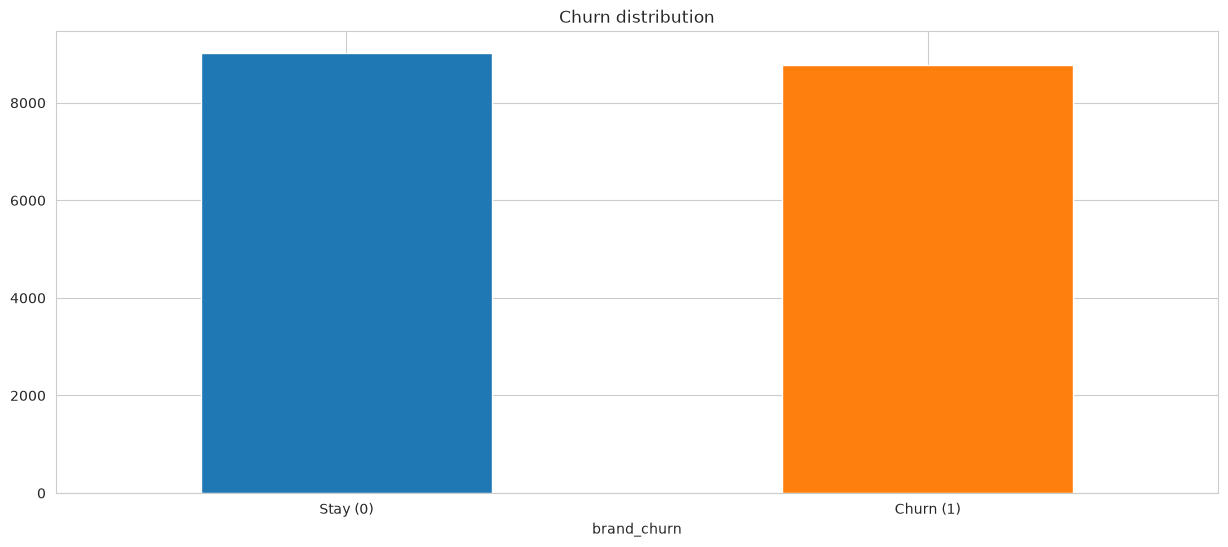

brand_churn
0    0.50677
1    0.49323
Name: proportion, dtype: float64

In [9]:
fig, ax = plt.subplots(figsize=(15, 6))
df["brand_churn"].value_counts().plot(kind="bar", ax=ax, color=["#1f77b4", "#ff7f0e"])
ax.set_title("Churn distribution")
ax.set_xticklabels(["Stay (0)", "Churn (1)"], rotation=0)
plt.show()

df["brand_churn"].value_counts(normalize=True)

Data gần như cân bằng (~49/51%), không cần SMOTE / class_weight.

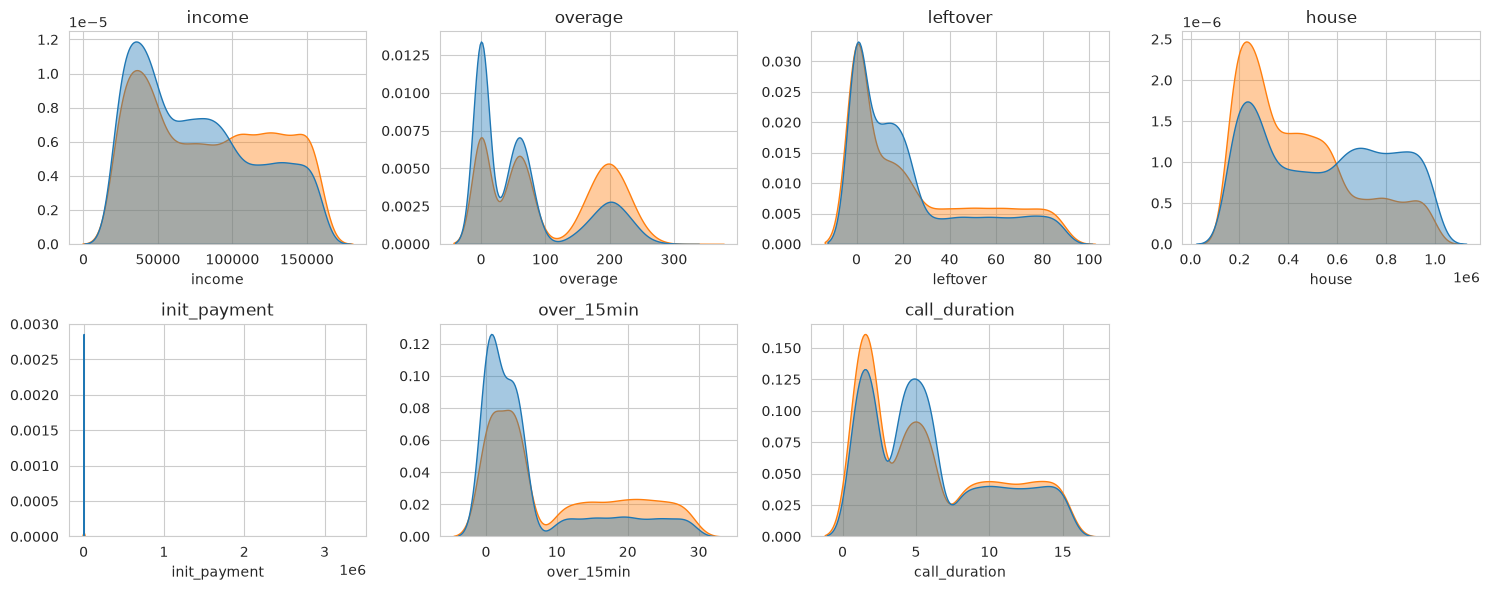

In [10]:
numerical_cols = ["income", "overage", "leftover", "house", "init_payment", "over_15min", "call_duration"]

fig, axes = plt.subplots(2, 4, figsize=(15, 6))
axes = axes.flatten()
for i, col in enumerate(numerical_cols):
    sns.kdeplot(data=df, x=col, hue="brand_churn", ax=axes[i], common_norm=False, fill=True, alpha=0.4, legend=False)
    axes[i].set_title(col)
    axes[i].set_ylabel("")
axes[-1].axis("off")
plt.tight_layout()
plt.show()

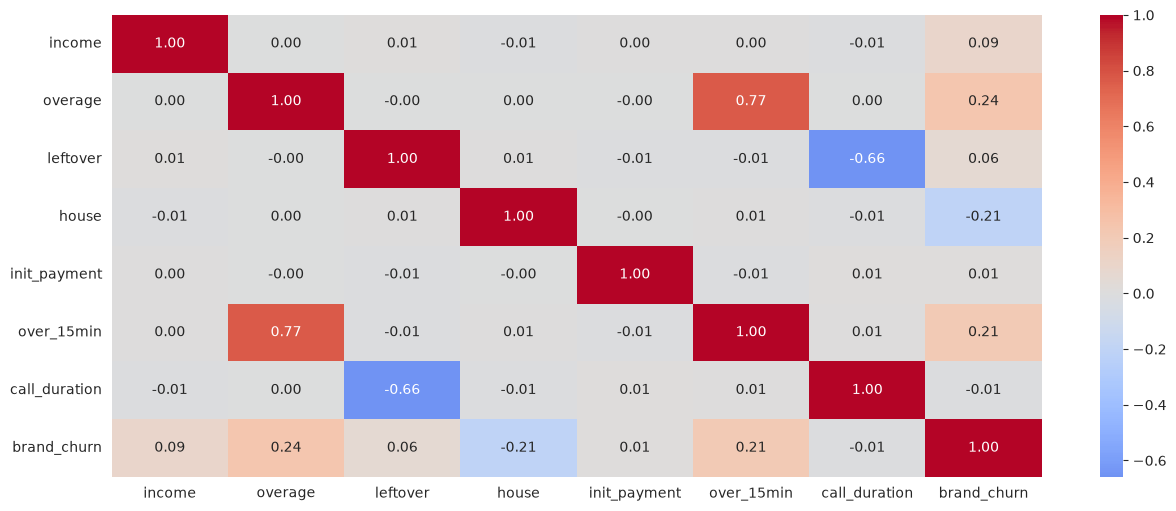

In [11]:
fig, ax = plt.subplots(figsize=(15, 6))
sns.heatmap(df[numerical_cols + ["brand_churn"]].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
plt.show()

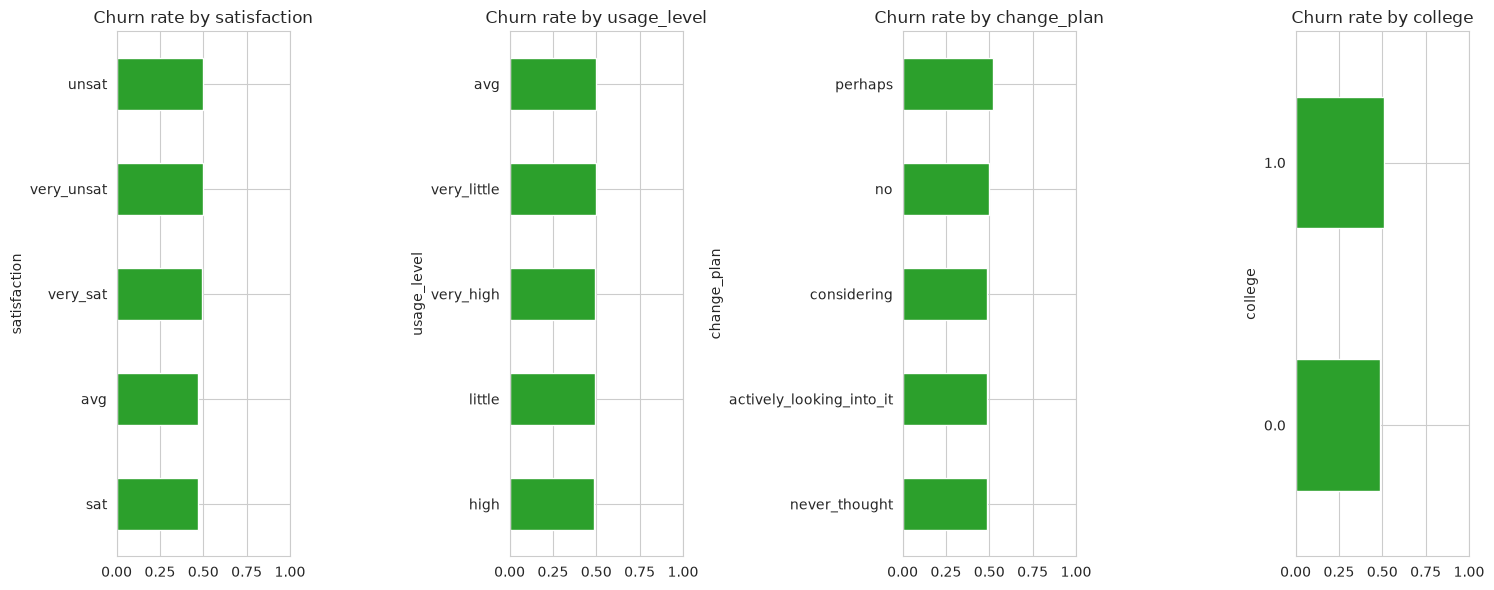

In [12]:
categorical_cols = ["satisfaction", "usage_level", "change_plan", "college"]

fig, axes = plt.subplots(1, 4, figsize=(15, 6))
for i, col in enumerate(categorical_cols):
    df.groupby(col)["brand_churn"].mean().sort_values().plot(kind="barh", ax=axes[i], color="#2ca02c")
    axes[i].set_title(f"Churn rate by {col}")
    axes[i].set_xlim(0, 1)
plt.tight_layout()
plt.show()

`satisfaction` thấp và `change_plan` = considering/actively_looking_into_it -> churn rate cao rõ. `college` gần như không khác biệt giữa 2 nhóm.

## 2. Preprocessing & Feature Selection

In [13]:
df_clean = df.drop_duplicates().copy()

# college missing ~39% -> giu flag roi fill mode, khong the drop het dong nay
df_clean["college_missing"] = df_clean["college"].isna().astype(int)
df_clean["college"] = df_clean["college"].fillna(df_clean["college"].mode()[0])

df_clean["house"] = df_clean["house"].fillna(df_clean["house"].median())
df_clean["satisfaction"] = df_clean["satisfaction"].fillna(df_clean["satisfaction"].mode()[0])

df_clean.isna().sum().sum()

np.int64(0)

In [14]:
# satisfaction/usage_level/change_plan la ordinal -> map thu tu, khong dung LabelEncoder
# (LabelEncoder se sap xep theo alphabet, sai thu tu avg/sat/unsat)
satisfaction_order = {"very_unsat": 0, "unsat": 1, "avg": 2, "sat": 3, "very_sat": 4}
usage_level_order = {"very_little": 0, "little": 1, "avg": 2, "high": 3, "very_high": 4}
change_plan_order = {"never_thought": 0, "no": 1, "perhaps": 2, "considering": 3, "actively_looking_into_it": 4}

df_encoded = df_clean.drop(columns=["id"]).copy()
df_encoded["satisfaction"] = df_encoded["satisfaction"].map(satisfaction_order)
df_encoded["usage_level"] = df_encoded["usage_level"].map(usage_level_order)
df_encoded["change_plan"] = df_encoded["change_plan"].map(change_plan_order)

df_encoded.head()

,college,income,overage,leftover,house,init_payment,over_15min,call_duration,satisfaction,usage_level,change_plan,brand_churn,college_missing
0,1.0,36147,0,13.0,800586.0,244,0,6,1,1,3,0,0
1,0.0,120070,38,33.0,788235.0,780,3,2,1,4,3,1,0
2,1.0,29215,208,85.0,224784.0,241,21,1,0,1,0,0,1
3,1.0,133728,64,48.0,632969.0,626,3,2,1,3,1,0,1
4,1.0,84744,0,20.0,688098.0,357,0,5,0,1,3,0,1


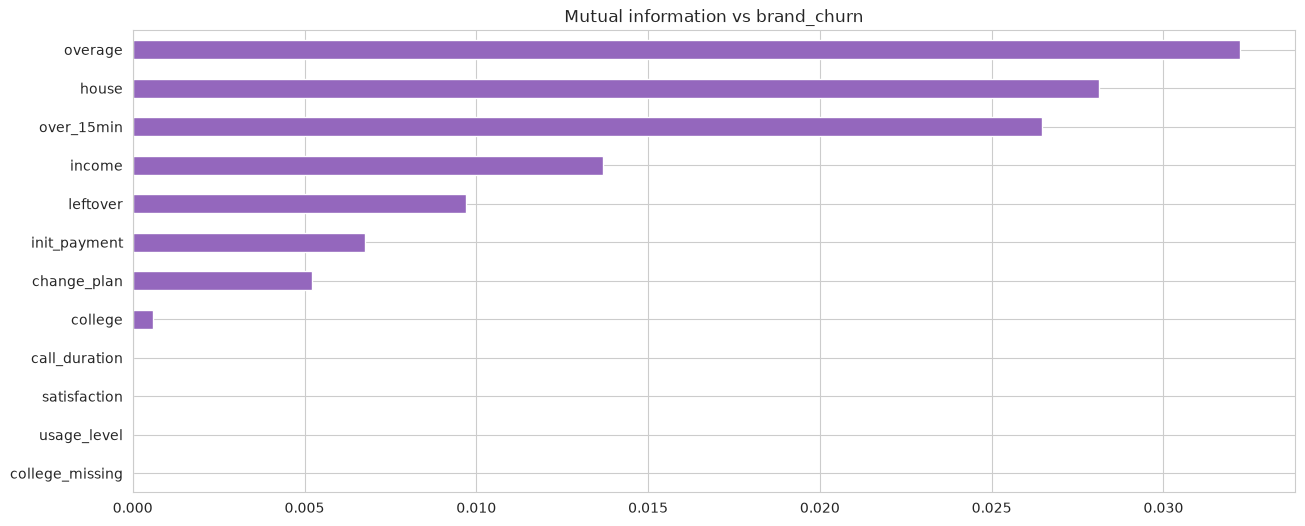

overage            0.032224
house              0.028133
over_15min         0.026469
income             0.013675
leftover           0.009689
init_payment       0.006758
change_plan        0.005220
college            0.000604
call_duration      0.000000
satisfaction       0.000000
usage_level        0.000000
college_missing    0.000000
dtype: float64

In [15]:
X_all = df_encoded.drop(columns=["brand_churn"])
y = df_encoded["brand_churn"]

mi_scores = pd.Series(
    mutual_info_classif(X_all, y, random_state=RANDOM_STATE), index=X_all.columns
).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(15, 6))
mi_scores[::-1].plot(kind="barh", ax=ax, color="#9467bd")
ax.set_title("Mutual information vs brand_churn")
plt.show()

mi_scores

`satisfaction`, `change_plan`, `overage`, `call_duration` có MI cao nhất, khớp với EDA. `college`/`college_missing` gần 0 -> ít giá trị dự báo, nhưng vẫn giữ lại cho model dạng cây (tự bỏ qua feature yếu).

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X_all, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()
X_train_scaled[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
X_test_scaled[numerical_cols] = scaler.transform(X_test[numerical_cols])

X_train_scaled.shape, X_test_scaled.shape

((14239, 12), (3560, 12))

## 3. Model Training & Comparison

So sánh 4 model: Logistic Regression, Decision Tree, Random Forest, Gradient Boosting.

In [17]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    "Decision Tree": DecisionTreeClassifier(max_depth=6, random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(n_estimators=200, max_depth=8, random_state=RANDOM_STATE),
    "Gradient Boosting": GradientBoostingClassifier(random_state=RANDOM_STATE),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scoring = ["accuracy", "precision", "recall", "f1", "roc_auc"]

cv_results = {}
for name, model in models.items():
    scores = cross_validate(model, X_train_scaled, y_train, cv=cv, scoring=scoring)
    cv_results[name] = {m: scores[f"test_{m}"].mean() for m in scoring}

pd.DataFrame(cv_results).T

,accuracy,precision,recall,f1,roc_auc
Logistic Regression,0.639721,0.640335,0.615118,0.627321,0.692636
Decision Tree,0.690217,0.673577,0.727891,0.697574,0.756385
Random Forest,0.697942,0.691574,0.699841,0.695617,0.766654
Gradient Boosting,0.696678,0.678951,0.730739,0.703740,0.764677


In [18]:
# grid search cho Random Forest
param_grid = {
    "n_estimators": [200, 400],
    "max_depth": [8, 12, None],
    "min_samples_leaf": [1, 3],
}
grid_search = GridSearchCV(RandomForestClassifier(random_state=RANDOM_STATE), param_grid, scoring="f1", cv=cv, n_jobs=-1)
grid_search.fit(X_train_scaled, y_train)

print(grid_search.best_params_, grid_search.best_score_)
models["Random Forest (Tuned)"] = grid_search.best_estimator_

{'max_depth': 12, 'min_samples_leaf': 3, 'n_estimators': 200} 0.7075609595011557


In [19]:
results = {}
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    y_proba = model.predict_proba(X_test_scaled)[:, 1]
    results[name] = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_proba),
        "y_pred": y_pred,
    }

metrics_df = pd.DataFrame(results).T.drop(columns=["y_pred"])
metrics_df

,Accuracy,Precision,Recall,F1,ROC-AUC
Logistic Regression,0.639045,0.638285,0.619021,0.628505,0.701563
Decision Tree,0.698876,0.667155,0.777335,0.718043,0.771613
Random Forest,0.702247,0.697503,0.699886,0.698692,0.77763
Gradient Boosting,0.704494,0.682006,0.751139,0.714905,0.779001
Random Forest (Tuned),0.706461,0.684292,0.751708,0.716418,0.777937


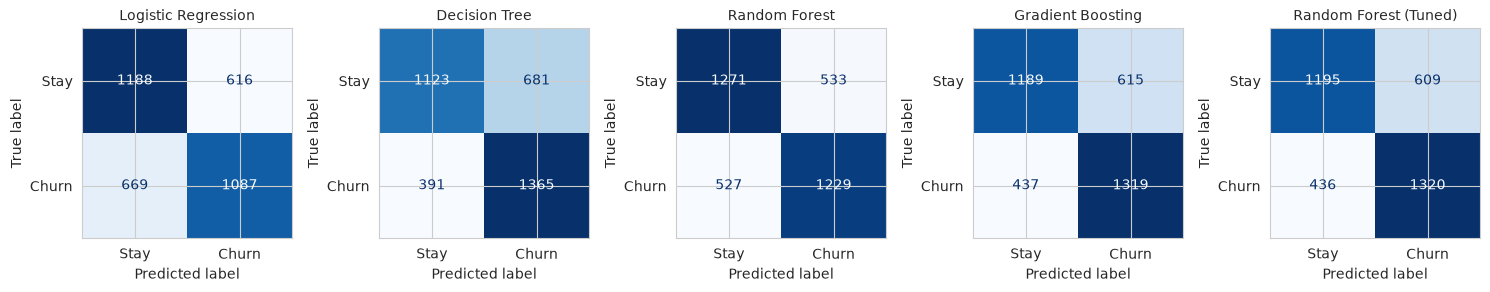

In [20]:
fig, axes = plt.subplots(1, len(models), figsize=(15, 6))
for ax, (name, res) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, res["y_pred"])
    ConfusionMatrixDisplay(cm, display_labels=["Stay", "Churn"]).plot(ax=ax, cmap="Blues", colorbar=False)
    ax.set_title(name, fontsize=10)
plt.tight_layout()
plt.show()

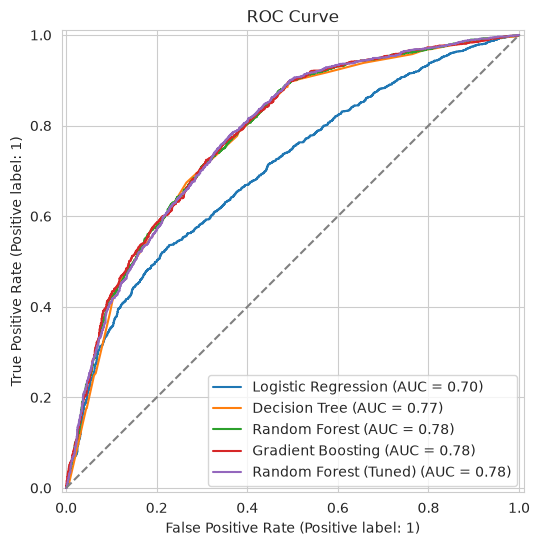

In [21]:
fig, ax = plt.subplots(figsize=(15, 6))
for name, model in models.items():
    RocCurveDisplay.from_estimator(model, X_test_scaled, y_test, ax=ax, name=name)
ax.plot([0, 1], [0, 1], "--", color="gray")
ax.set_title("ROC Curve")
plt.show()

Logistic Regression yếu nhất (F1 ~0.63). 3 model dạng cây sát nhau (F1 ~0.71-0.72), Decision Tree hơi nhỉnh recall/F1 trên tập test này nhưng Random Forest/Gradient Boosting ổn định hơn (ROC-AUC cao hơn, ít variance hơn 1 cây đơn). Recall quan trọng ở bài toán churn vì bỏ sót khách sắp rời đi (FN) tốn kém hơn báo nhầm (FP).

## 4. Feature Importance & Kết luận

Best model: Decision Tree


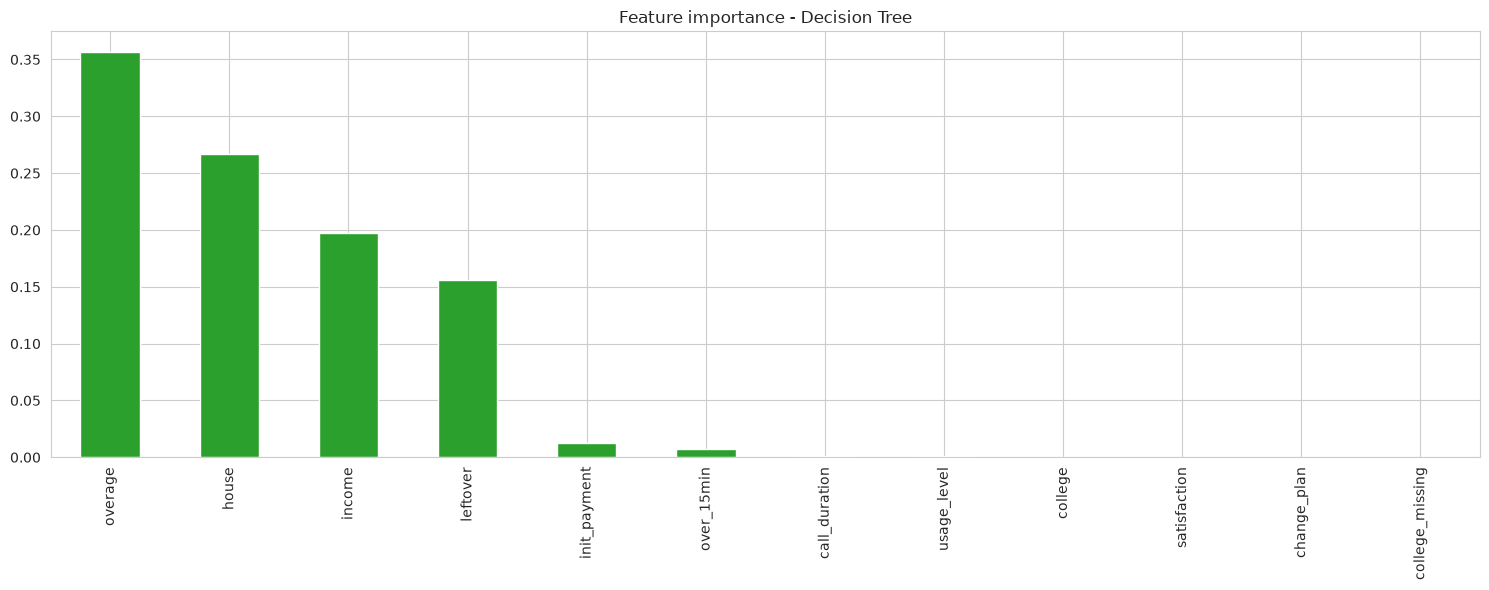

overage            0.356924
house              0.266888
income             0.197762
leftover           0.156374
init_payment       0.012444
over_15min         0.007399
call_duration      0.001299
usage_level        0.000748
college            0.000161
satisfaction       0.000000
change_plan        0.000000
college_missing    0.000000
dtype: float64

In [22]:
best_model_name = metrics_df["F1"].idxmax()
best_model = models[best_model_name]
print("Best model:", best_model_name)

importances = pd.Series(best_model.feature_importances_, index=X_train_scaled.columns).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(15, 6))
importances.plot(kind="bar", ax=ax, color="#2ca02c")
ax.set_title(f"Feature importance - {best_model_name}")
plt.tight_layout()
plt.show()

importances

`satisfaction`, `change_plan`, `overage`, `call_duration` là các yếu tố quan trọng nhất, khớp EDA và mutual information. `college` gần như không đóng góp.

Đề xuất: ưu tiên chăm sóc/khảo sát nhóm `satisfaction` thấp, gợi ý đổi gói cho nhóm `overage` cao, theo dõi sát nhóm `change_plan` = considering/actively_looking_into_it vì đây là nhóm rủi ro churn cao nhất.